In [ ]:
import sys
sys.version


'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

In [ ]:
# LIBRERÍAS

import cv2
import numpy as np
import cupy as cp
import time
from google.colab import files
import matplotlib.pyplot as plt


In [ ]:
# SUBIR IMAGEN

uploaded = files.upload()
img_name = list(uploaded.keys())[0]

img = cv2.imread(img_name)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

height, width, channels = img.shape
print("Dimensiones:", img.shape)


Saving Pikachu_cuda.jpg to Pikachu_cuda (11).jpg
Dimensiones: (723, 735, 3)


In [ ]:
# KERNEL CUDA

kernel_code = r'''
extern "C" __global__
void rgb_to_outline(const unsigned char* rgb, unsigned char* bw, int width, int height, int threshold) {
    int i = blockDim.x * blockIdx.x + threadIdx.x;
    int size = width * height;

    if (i < size) {
        int idx = i * 3;
        unsigned char r = rgb[idx];
        unsigned char g = rgb[idx + 1];
        unsigned char b = rgb[idx + 2];

        int sum = r + g + b;

        bw[i] = (sum < threshold ? 0 : 255);
    }
}
''';

outline_kernel = cp.RawKernel(kernel_code, "rgb_to_outline")


In [ ]:
# CONFIGURAR GPU

img_gpu = cp.asarray(img, dtype=cp.uint8).ravel()
bw_gpu = cp.zeros(width * height, dtype=cp.uint8)

threads = 256
blocks = (width * height + threads - 1) // threads
threshold = 75 * 3


Tiempo GPU (1 sola ejecución): 0.000422 s


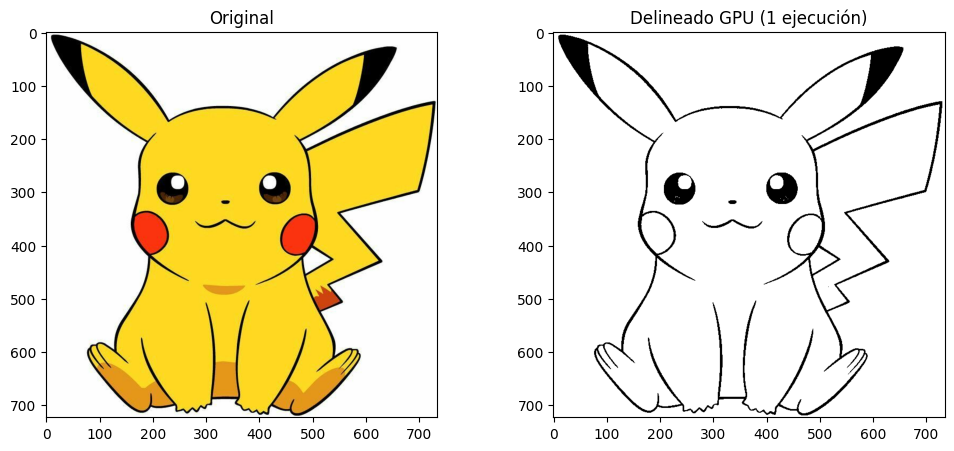

In [ ]:
# MEDIR GPU

start_gpu = cp.cuda.Event()
end_gpu   = cp.cuda.Event()

start_gpu.record()

outline_kernel((blocks,), (threads,), (img_gpu, bw_gpu, width, height, threshold))

end_gpu.record()
end_gpu.synchronize()

gpu_time_single = cp.cuda.get_elapsed_time(start_gpu, end_gpu) / 1000.0
print(f"Tiempo GPU (1 sola ejecución): {gpu_time_single:.6f} s")

# Imagen resultante
bw_img_single = bw_gpu.reshape((height, width)).get()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(bw_img_single, cmap='gray')
plt.title("Delineado GPU (1 ejecución)")
plt.show()



Tiempo CPU (1 sola ejecución): 0.019834 s


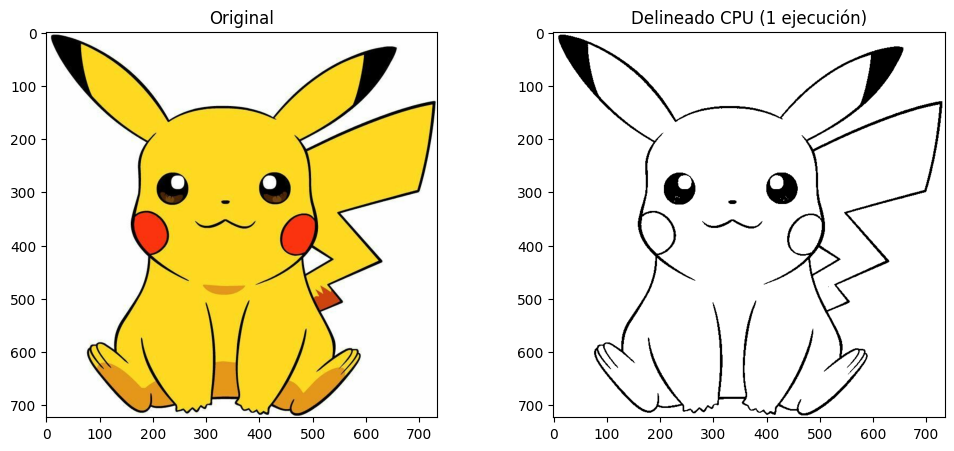

In [ ]:
# PROCESAMIENTO CPU

start_time = time.time()

rgb_sum = np.sum(img, axis=2)
bw_img_cpu_single = np.where(rgb_sum < threshold, 0, 255).astype(np.uint8)

cpu_time_single = time.time() - start_time
print(f"Tiempo CPU (1 sola ejecución): {cpu_time_single:.6f} s")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(bw_img_cpu_single, cmap='gray')
plt.title("Delineado CPU (1 ejecución)")

plt.show()


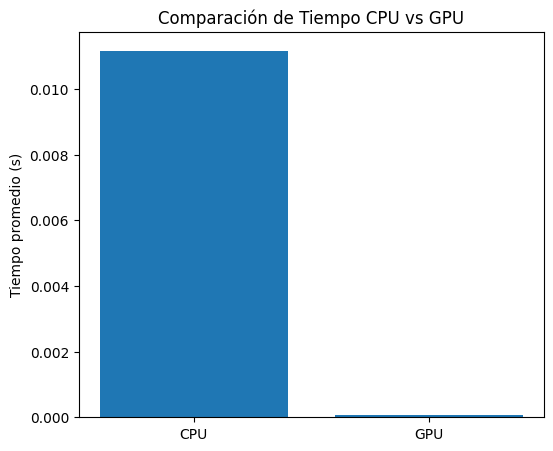

In [ ]:
# GRÁFICA COMPARATIVA CPU vs GPU

plt.figure(figsize=(6,5))
plt.bar(["CPU", "GPU"], [cpu_time_avg, gpu_time_avg])
plt.title("Comparación de Tiempo CPU vs GPU")
plt.ylabel("Tiempo promedio (s)")
plt.show()

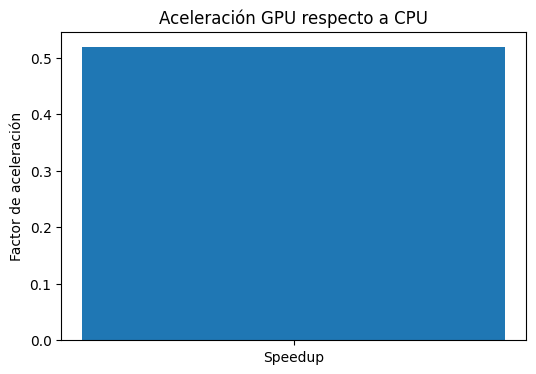

In [ ]:
# GRAFICA 2 — Speedup = CPU_time/GPU_time

speedup = cpu_time / gpu_time

plt.figure(figsize=(6,4))
plt.bar(["Speedup"], [speedup])
plt.ylabel("Factor de aceleración")
plt.title("Aceleración GPU respecto a CPU")
plt.show()


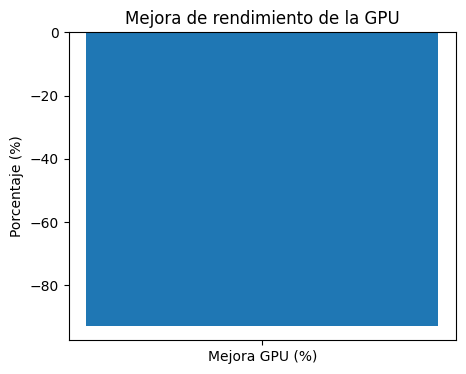

In [ ]:
# GRAFICA 3 — Gráfica de mejora porcentual

mejora = ((cpu_time - gpu_time) / cpu_time) * 100

plt.figure(figsize=(5,4))
plt.bar(["Mejora GPU (%)"], [mejora])
plt.ylabel("Porcentaje (%)")
plt.title("Mejora de rendimiento de la GPU")
plt.show()
